In [1]:
import os, re, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score)

nltk.download("stopwords", quiet=True)
sns.set_theme(style="whitegrid")

train = pd.read_csv("../data/processed/train.csv").dropna().reset_index(drop=True)
test = pd.read_csv("../data/processed/test.csv").dropna().reset_index(drop=True)
X_train, y_train = train["text_clean"], train["label"].values
X_test, y_test = test["text_clean"], test["label"].values


def construire_modele():
    return Pipeline([
        ("tfidf", TfidfVectorizer(min_df=3, max_df=0.95, max_features=50000, ngram_range=(1, 2))),
        ("svm", LinearSVC(C=1.0, random_state=42))
    ])


def metriques(y, pred):
    tn, fp_n, fn_n, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {"accuracy": accuracy_score(y, pred),
            "précision": precision_score(y, pred, zero_division=0),
            "rappel": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0),
            "faux_positifs": int(fp_n), "faux_négatifs": int(fn_n)}

In [2]:
modele = construire_modele()
modele.fit(X_train, y_train)
y_pred = modele.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Non-spam", "Spam"], digits=4))
print(metriques(y_test, y_pred))

os.makedirs("../models", exist_ok=True)
joblib.dump(modele, "../models/svm_final.joblib")

              precision    recall  f1-score   support

    Non-spam     0.9952    0.9889    0.9921      3159
        Spam     0.9876    0.9946    0.9911      2795

    accuracy                         0.9916      5954
   macro avg     0.9914    0.9918    0.9916      5954
weighted avg     0.9916    0.9916    0.9916      5954

{'accuracy': 0.9916022841787034, 'précision': 0.9875666074600356, 'rappel': 0.9946332737030411, 'f1': 0.9910873440285205, 'faux_positifs': 35, 'faux_négatifs': 15}


['../models/svm_final.joblib']

In [3]:
test["pred"] = y_pred
test["nb_mots"] = test["text_clean"].str.split().str.len()
fp = test[(test["label"] == 0) & (test["pred"] == 1)]
fn = test[(test["label"] == 1) & (test["pred"] == 0)]
print(f"{len(fp)} faux positifs | {len(fn)} faux négatifs\n")

def afficher(df, n=6, seed=1):
    for _, l in df.sample(min(n, len(df)), random_state=seed).iterrows():
        print(f"[{l['nb_mots']} mots] {l['text_clean'][:300]}\n")

print("===== FAUX POSITIFS (emails légitimes classés spam) =====")
afficher(fp)
print("===== FAUX NÉGATIFS (spams non détectés) =====")
afficher(fn)

35 faux positifs | 15 faux négatifs

===== FAUX POSITIFS (emails légitimes classés spam) =====
[14 mots] invitation dinner music started clicking sound icon stop music right click end show heather

[140 mots] eta link hyperlink active eta change number country id accordingly http www enrononline com docs eta eta nombre html uk http www enrononline com docs eta eta nombre html us country id country name nombre argentina nombre australia nombre austria nombre belgium nombre bermuda nombre canada nombre cay

[13 mots] important video announcement important video announcement future company please go access video thank

[181 mots] fw computers happy holidays bonnie hitschel nombre nombre nombre subject computers dear tech support last year upgraded boyfriend nombre nombre husband nombre nombre noticed slowdown performance flower jewelry applications operated flawlessly boyfriend nombre nombre addition husband nombre nombre un

[21 mots] jargon nombre technical terminology characteristic id

In [4]:
test["erreur"] = test["label"] != test["pred"]
test["tranche"] = pd.cut(test["nb_mots"], bins=[0, 20, 50, 100, 200, 500, np.inf],
                         labels=["≤20", "21-50", "51-100", "101-200", "201-500", ">500"])
tab = test.groupby("tranche", observed=True).agg(emails=("erreur", "size"), erreurs=("erreur", "sum"))
tab["taux_erreur_%"] = (100 * tab["erreurs"] / tab["emails"]).round(2)
tab

,emails,erreurs,taux_erreur_%
tranche,,,
≤20,574,23,4.01
21-50,1573,6,0.38
51-100,1483,4,0.27
101-200,1214,12,0.99
201-500,850,5,0.59
>500,260,0,0.00


Seuil retenu : 0.25


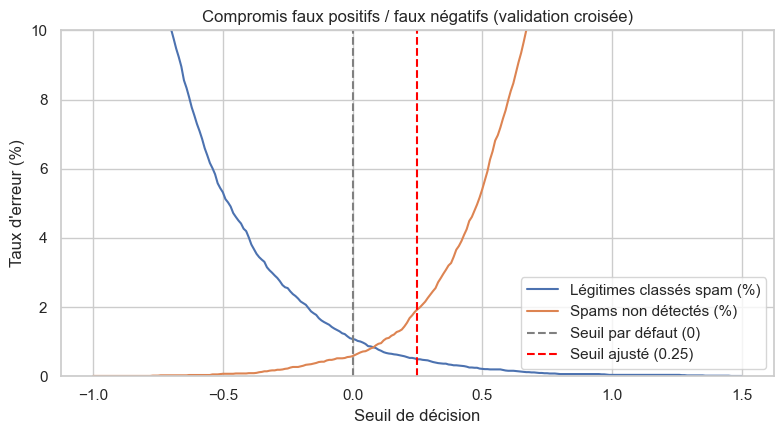

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_oof = cross_val_predict(construire_modele(), X_train, y_train, cv=cv,
                               method="decision_function", n_jobs=-1)

ths = np.linspace(-1.0, 1.5, 251)
n_legit, n_spam = (y_train == 0).sum(), (y_train == 1).sum()
taux_fp = np.array([((scores_oof >= t) & (y_train == 0)).sum() / n_legit for t in ths])
rappel_cv = np.array([((scores_oof >= t) & (y_train == 1)).sum() / n_spam for t in ths])

CIBLE_FP = 0.005                       # au plus 0,5 % d'emails légitimes bloqués
seuil = ths[taux_fp <= CIBLE_FP].min()
print(f"Seuil retenu : {seuil:.2f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ths, 100 * taux_fp, label="Légitimes classés spam (%)")
ax.plot(ths, 100 * (1 - rappel_cv), label="Spams non détectés (%)")
ax.axvline(0, color="gray", ls="--", label="Seuil par défaut (0)")
ax.axvline(seuil, color="red", ls="--", label=f"Seuil ajusté ({seuil:.2f})")
ax.set_xlabel("Seuil de décision")
ax.set_ylabel("Taux d'erreur (%)")
ax.set_ylim(0, 10)
ax.set_title("Compromis faux positifs / faux négatifs (validation croisée)")
ax.legend()
plt.tight_layout()
plt.savefig("../images/09_seuil_decision.png", dpi=150)
plt.show()

In [6]:
scores_test = modele.decision_function(X_test)
print("AUC sur le test : {:.4f}".format(roc_auc_score(y_test, scores_test)))

lignes = []
for nom, t in [("Seuil par défaut (0)", 0.0), (f"Seuil ajusté ({seuil:.2f})", seuil)]:
    lignes.append({"seuil": nom, **metriques(y_test, (scores_test >= t).astype(int))})
pd.DataFrame(lignes).round(4)

AUC sur le test : 0.9994


,seuil,accuracy,précision,rappel,f1,faux_positifs,faux_négatifs
0,Seuil par défaut (0),0.9916,0.9876,0.9946,0.9911,35,15
1,Seuil ajusté (0.25),0.9884,0.9921,0.9832,0.9876,22,47


In [7]:
# On ajoute cette variante au tableau comparatif général
chemin = "../data/processed/resultats.csv"
ligne = {"modèle": "SVM optimisé (seuil ajusté)",
         **metriques(y_test, (scores_test >= seuil).astype(int)),
         "f1_validation_croisée": np.nan, "temps_entraînement_s": np.nan}
res = pd.read_csv(chemin)
res = res[res["modèle"] != ligne["modèle"]]
pd.concat([res, pd.DataFrame([ligne])], ignore_index=True).to_csv(chemin, index=False)

In [8]:
MARQUEURS_ENRON = {"enron", "ect", "hou", "hpl", "ena", "vince", "kaminski", "louise", "daren",
                   "hourahead", "westdesk", "dynegy", "houston", "portland", "mmbtu"}

def retirer(serie):
    return serie.apply(lambda t: " ".join(m for m in t.split() if m not in MARQUEURS_ENRON))

modele_sans = construire_modele()
modele_sans.fit(retirer(X_train), y_train)
pred_sans = modele_sans.predict(retirer(X_test))

comparaison = pd.DataFrame([
    {"variante": "Modèle final (texte complet)", **metriques(y_test, y_pred)},
    {"variante": "Sans marqueurs Enron", **metriques(y_test, pred_sans)},
])
comparaison.round(4)

,variante,accuracy,précision,rappel,f1,faux_positifs,faux_négatifs
0,Modèle final (texte complet),0.9916,0.9876,0.9946,0.9911,35,15
1,Sans marqueurs Enron,0.9884,0.9851,0.9903,0.9877,42,27
